**Question 1: Build a simple autoencoder in Python using Keras to compress and reconstruct 28x28 grayscale images from the Fashion MNIST dataset. Train for 5 epochs and display one original and its reconstructed image side by side.**

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - loss: 0.0392 - val_loss: 0.0221
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0178 - val_loss: 0.0151
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0135 - val_loss: 0.0126
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0119 - val_loss: 0.0114
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0109 - val_loss: 0.0106
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


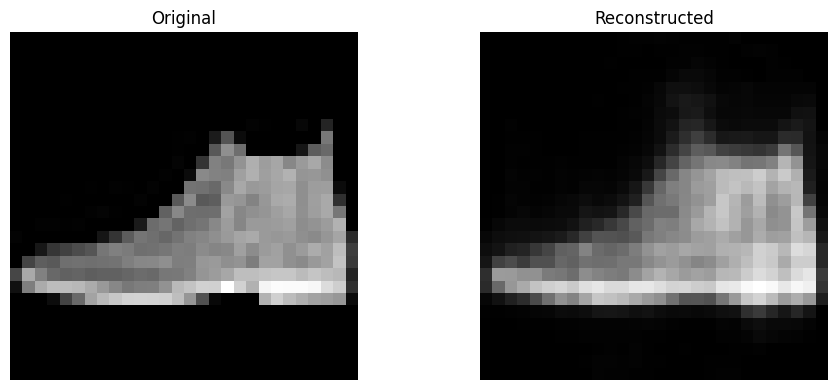

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Flatten, Reshape

(x_train, _), (x_test, _) = fashion_mnist.load_data()

# Normalize pixel values to [0,1]
X_train = x_train.astype('float32') / 255.0
X_test = x_test.astype('float32') / 255.0

input_shape = (28,28)

# Encoder

input_img = Input(shape=input_shape)
x = Flatten()(input_img)
encoded = Dense(64, activation='relu')(x)

# Decoder
x = Dense(784, activation='sigmoid')(encoded)
decoded = Reshape(input_shape)(x)

# Autoencoder model
autoencoder = Model(input_img, decoded)

# Compile the model

autoencoder.compile(optimizer='adam', loss='mse')

# Model training

autoencoder.fit(X_train, X_train, epochs=5, batch_size=128, shuffle=True, validation_data=(X_test, X_test))

# Reconstruct an image

reconstruct = autoencoder.predict(X_test)

# Display original and reconstructed image

plt.figure(figsize=(10,4))

# Original
plt.subplot(1,2,1)
plt.imshow(X_test[0], cmap='gray')
plt.title('Original')
plt.axis('off')

# Reconstructed

plt.subplot(1,2,2)
plt.imshow(reconstruct[0], cmap='gray')
plt.title('Reconstructed')
plt.axis('off')

plt.tight_layout()
plt.show()

**Question 2:**
**Modify your autoencoder's loss function to use Binary Crossentropy (BCE) instead of Mean Squared Error (MSE). Then, compare the reconstruction quality visually by displaying the original and reconstructed versions of three test images side by side.**

**Hint: Use the following when compiling the model:**

**model.compile(loss='binary_crossentropy', optimizer='adam')**  

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 0.3553 - val_loss: 0.3095
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.2967 - val_loss: 0.2909
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.2849 - val_loss: 0.2838
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.2799 - val_loss: 0.2804
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.2772 - val_loss: 0.2783
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


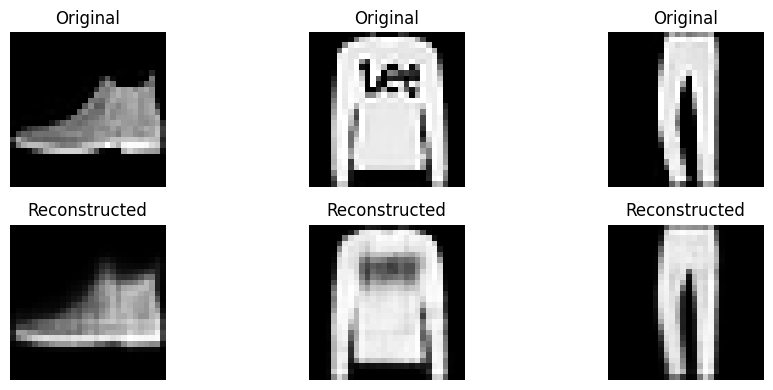

In [ ]:
# So previously we have used MSE as loss function and now we are using binary cross-entropy (Loss function)


import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Flatten, Reshape

(x_train, _), (x_test, _) = fashion_mnist.load_data()

# Normalize pixel values to [0,1]
X_train = x_train.astype('float32') / 255.0
X_test = x_test.astype('float32') / 255.0

input_shape = (28,28)

# Encoder

input_img = Input(shape=input_shape)
x = Flatten()(input_img)
encoded = Dense(64, activation='relu')(x)

# Decoder
x = Dense(784, activation='sigmoid')(encoded)
decoded = Reshape(input_shape)(x)

# Autoencoder model
autoencoder = Model(input_img, decoded)

# Compile the model (From mse to binary_crossentropy)

autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# Model training

autoencoder.fit(X_train, X_train, epochs=5, batch_size=128, shuffle=True, validation_data=(X_test, X_test))

# Reconstruct an image

reconstruct = autoencoder.predict(X_test)

# Plotting three original images alongside their reconstructed outputs.

plt.figure(figsize=(10,4))

for i in range(3):
  # Original
  plt.subplot(2,3,i+1)
  plt.imshow(X_test[i], cmap='gray')
  plt.title('Original')
  plt.axis('off')

  # Reconstructed

  plt.subplot(2,3,i+4)
  plt.imshow(reconstruct[i], cmap='gray')
  plt.title('Reconstructed')
  plt.axis('off')




plt.tight_layout()
plt.show()

**Question 3: Use your trained autoencoder to denoise images: add random noise to 10 Fashion MNIST test images, pass them through the autoencoder, and display the noisy and denoised outputs together.**


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


<function matplotlib.pyplot.show(close=None, block=None)>

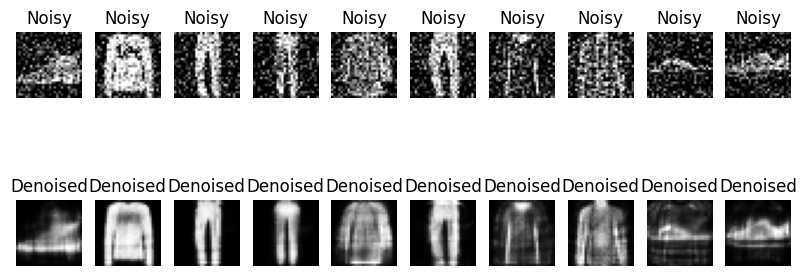

In [ ]:
# Adding random noise
noise_factor = 0.3
noisy_images = X_test + noise_factor * np.random.randn(*X_test.shape)
noisy_images = np.clip(noisy_images, 0, 1)

# Denoising
denoised_images = autoencoder.predict(noisy_images)

# Displaying 10 noisy and denoised images

plt.figure(figsize=(10,4))

for i in range(10):

  # Noisy image

  plt.subplot(2,10,i+1)
  plt.imshow(noisy_images[i], cmap='gray')
  plt.title('Noisy')
  plt.axis('off')

  # Denoised
  plt.subplot(2,10,i+11)
  plt.imshow(denoised_images[i], cmap='gray')
  plt.title('Denoised')
  plt.axis('off')


plt.show



**Question 4: Use ChatGPT to explain in your own words what KL-divergence loss does in a VAE and why it is needed. Paste your prompt and ChatGPT's response as your answer.**

Ans:

**Prompt:**

Explain in simple words what the KL-divergence loss does in a Variational Autoencoder (VAE) and why it is needed.

**Response:**

KL-divergence loss is a part of the loss function in a Variational Autoencoder (VAE). Its main purpose is to make the latent space follow a standard normal distribution (mean = 0 and variance = 1). This keeps the latent representations organized and prevents the encoder from placing similar images at random locations in the latent space.

This is important because, after training, we generate new images by sampling random points from the latent space. If the latent space is not properly organized, the decoder may generate unrealistic or distorted images. KL-divergence ensures that nearby points in the latent space produce similar and meaningful outputs, making the model capable of generating smooth, realistic, and diverse images.

In simple terms, the reconstruction loss helps the VAE recreate the input image accurately, while the KL-divergence loss organizes the latent space so that new images can be generated successfully from random samples.
